In [1]:
# Install required packages
!pip -q install openpyxl xlrd odfpy py7zr pymupdf python-docx \
    scipy h5py openpyxl librosa wordcloud pydicom SimpleITK \
    scikit-image liac-arff

# Import libraries
import os
import re
import json
import zipfile
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings("ignore")

print("Environment ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.8 MB/s eta 0:00:00
Environment ready!


In [2]:
import requests

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

response = requests.get(url)

with open("iris.csv", "wb") as f:
    f.write(response.content)

print("iris.csv downloaded successfully")
print("File size:", os.path.getsize("iris.csv"), "bytes")

iris.csv downloaded successfully
File size: 3858 bytes


In [3]:
df_csv = pd.read_csv("iris.csv")

print(df_csv.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print("Shape:", df_csv.shape)
print("Dimensions:", df_csv.ndim)
print("Number of rows:", len(df_csv))
print("Number of columns:", len(df_csv.columns))
print("Columns:", list(df_csv.columns))
print("\nData types:")
print(df_csv.dtypes)
print("\nFile size:", os.path.getsize("iris.csv"), "bytes")

Shape: (150, 5)
Dimensions: 2
Number of rows: 150
Number of columns: 5
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

File size: 3858 bytes


In [5]:
df_csv.to_csv("iris.dat", sep="\t", index=False)

df_dat = pd.read_csv("iris.dat", sep="\t")

print(df_dat.head())
print("Shape:", df_dat.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [6]:
df_csv.to_csv("iris.tsv", sep="\t", index=False)

df_tsv = pd.read_csv("iris.tsv", sep="\t")

print(df_tsv.head())
print("Shape:", df_tsv.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [7]:
df_csv.to_excel("iris.xlsx", index=False)

df_xlsx = pd.read_excel("iris.xlsx")

print(df_xlsx.head())
print("Shape:", df_xlsx.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [8]:
df_csv.to_excel("iris.ods", engine="odf", index=False)

df_ods = pd.read_excel("iris.ods", engine="odf")

print(df_ods.head())
print("Shape:", df_ods.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [9]:
from scipy.io import arff

# Create a simple ARFF file
with open("iris.arff", "w") as f:
    f.write("""@RELATION iris

@ATTRIBUTE sepal_length NUMERIC
@ATTRIBUTE sepal_width NUMERIC
@ATTRIBUTE petal_length NUMERIC
@ATTRIBUTE petal_width NUMERIC
@ATTRIBUTE species {setosa,versicolor,virginica}

@DATA
""")

    for _, row in df_csv.iterrows():
        f.write(
            f"{row.sepal_length},{row.sepal_width},"
            f"{row.petal_length},{row.petal_width},{row.species}\n"
        )

data, meta = arff.loadarff("iris.arff")

df_arff = pd.DataFrame(data)

print(df_arff.head())
print("Shape:", df_arff.shape)
print("Dimensions:", df_arff.ndim)

   sepal_length  sepal_width  petal_length  petal_width    species
0           5.1          3.5           1.4          0.2  b'setosa'
1           4.9          3.0           1.4          0.2  b'setosa'
2           4.7          3.2           1.3          0.2  b'setosa'
3           4.6          3.1           1.5          0.2  b'setosa'
4           5.0          3.6           1.4          0.2  b'setosa'
Shape: (150, 5)
Dimensions: 2


In [10]:
df_csv.to_json("iris.json", orient="records", indent=4)

with open("iris.json", "r") as f:
    json_data = json.load(f)

print(json_data[:3])
print("Number of records:", len(json_data))
print("File size:", os.path.getsize("iris.json"), "bytes")

[{'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2, 'species': 'setosa'}, {'sepal_length': 4.9, 'sepal_width': 3.0, 'petal_length': 1.4, 'petal_width': 0.2, 'species': 'setosa'}, {'sepal_length': 4.7, 'sepal_width': 3.2, 'petal_length': 1.3, 'petal_width': 0.2, 'species': 'setosa'}]
Number of records: 150
File size: 22852 bytes


In [11]:
df_csv.to_html("iris.html", index=False)

df_html = pd.read_html("iris.html")[0]

print(df_html.head())
print("Shape:", df_html.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [12]:
df_csv.to_xml("iris.xml", index=False)

df_xml = pd.read_xml("iris.xml")

print(df_xml.head())
print("Shape:", df_xml.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [13]:
df_csv.to_pickle("iris.pkl")

df_pkl = pd.read_pickle("iris.pkl")

print(df_pkl.head())
print("Shape:", df_pkl.shape)
print("File size:", os.path.getsize("iris.pkl"), "bytes")

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)
File size: 5933 bytes


In [14]:
numeric_data = df_csv.iloc[:, :4].values

# NPY
np.save("iris.npy", numeric_data)

loaded_npy = np.load("iris.npy")

print("NPY data:")
print(loaded_npy[:5])
print("Shape:", loaded_npy.shape)
print("Dimensions:", loaded_npy.ndim)

NPY data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Shape: (150, 4)
Dimensions: 2


In [15]:
np.savez(
    "iris.npz",
    data=numeric_data,
    labels=df_csv["species"].values
)

loaded_npz = np.load("iris.npz")

print("Arrays stored in NPZ:", loaded_npz.files)
print("Data shape:", loaded_npz["data"].shape)

Arrays stored in NPZ: ['data', 'labels']
Data shape: (150, 4)


In [16]:
with zipfile.ZipFile("iris.zip", "w") as z:
    z.write("iris.csv")

print("ZIP created successfully")

with zipfile.ZipFile("iris.zip", "r") as z:
    print("Files inside ZIP:", z.namelist())

ZIP created successfully
Files inside ZIP: ['iris.csv']


In [17]:
import sqlite3

connection = sqlite3.connect("iris.db")

df_csv.to_sql(
    "iris",
    connection,
    if_exists="replace",
    index=False
)

query = "SELECT * FROM iris"

df_sql = pd.read_sql(query, connection)

print(df_sql.head())
print("Shape:", df_sql.shape)

connection.close()

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)


In [18]:
from scipy.io import savemat, loadmat

savemat(
    "iris.mat",
    {"iris_data": numeric_data}
)

mat_data = loadmat("iris.mat")

print(mat_data.keys())
print("MAT data shape:", mat_data["iris_data"].shape)

dict_keys(['__header__', '__version__', '__globals__', 'iris_data'])
MAT data shape: (150, 4)


In [19]:
import h5py

with h5py.File("iris.h5", "w") as f:
    f.create_dataset("iris_data", data=numeric_data)

with h5py.File("iris.h5", "r") as f:
    data = f["iris_data"][:]

print(data[:5])
print("Shape:", data.shape)
print("Dimensions:", data.ndim)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Shape: (150, 4)
Dimensions: 2


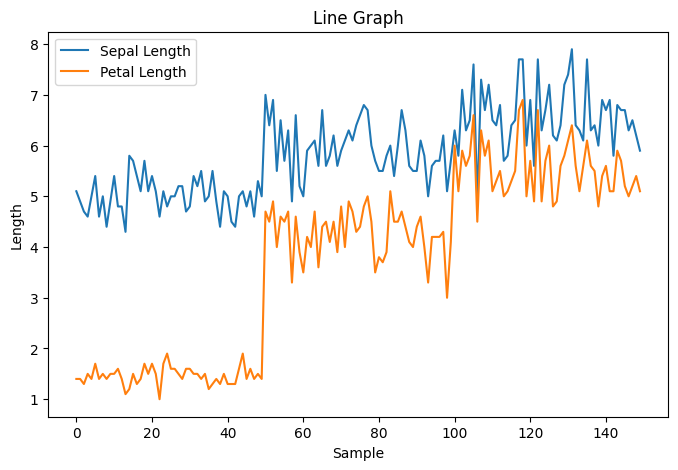

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    df_csv.index,
    df_csv["sepal_length"],
    label="Sepal Length"
)

plt.plot(
    df_csv.index,
    df_csv["petal_length"],
    label="Petal Length"
)

plt.xlabel("Sample")
plt.ylabel("Length")
plt.title("Line Graph")
plt.legend()
plt.show()

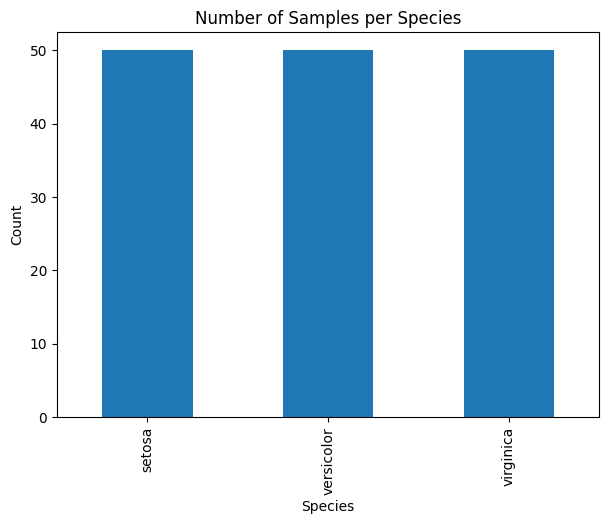

In [21]:
species_count = df_csv["species"].value_counts()

plt.figure(figsize=(7,5))
species_count.plot(kind="bar")

plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Number of Samples per Species")
plt.show()

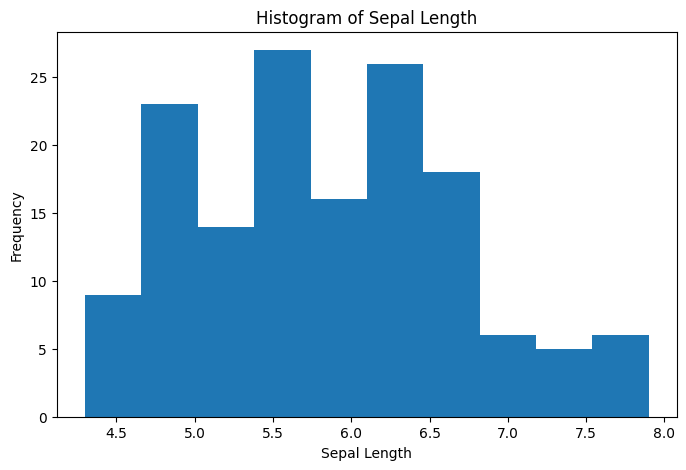

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    df_csv["sepal_length"],
    bins=10
)

plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.title("Histogram of Sepal Length")
plt.show()

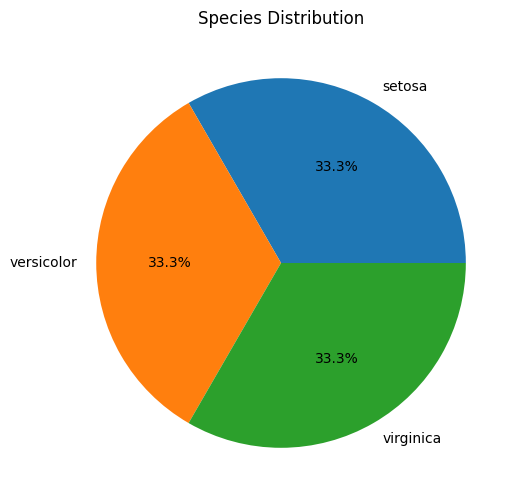

In [23]:
plt.figure(figsize=(6,6))

df_csv["species"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Species Distribution")
plt.show()

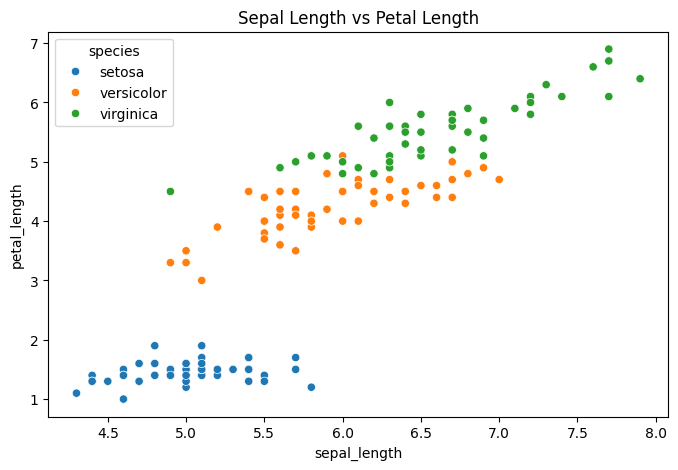

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_csv,
    x="sepal_length",
    y="petal_length",
    hue="species"
)

plt.title("Sepal Length vs Petal Length")
plt.show()

Status code: 200
Content type: image/jpeg
Image format: JPEG
Image size: (1546, 1213)
Image mode: RGB
Image dimensions: 3


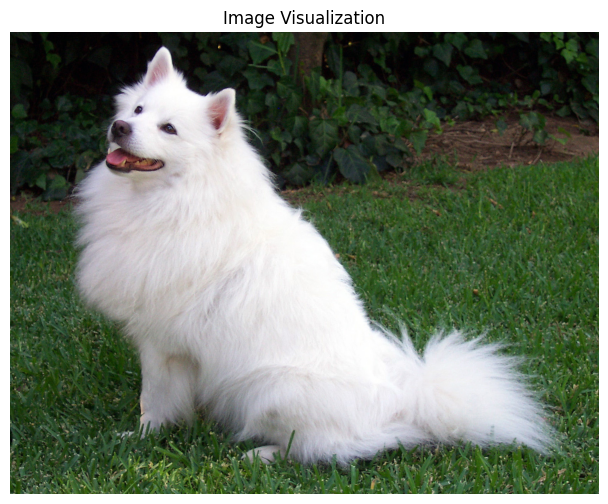

In [26]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Direct image URL
image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

# Download image
response = requests.get(image_url)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

# Check whether the response is actually an image
if response.status_code == 200 and "image" in response.headers.get("Content-Type", ""):

    image = Image.open(BytesIO(response.content))

    print("Image format:", image.format)
    print("Image size:", image.size)
    print("Image mode:", image.mode)
    print("Image dimensions:", len(image.getbands()))

    # Display image
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Image Visualization")
    plt.show()

else:
    print("Failed to download a valid image.")

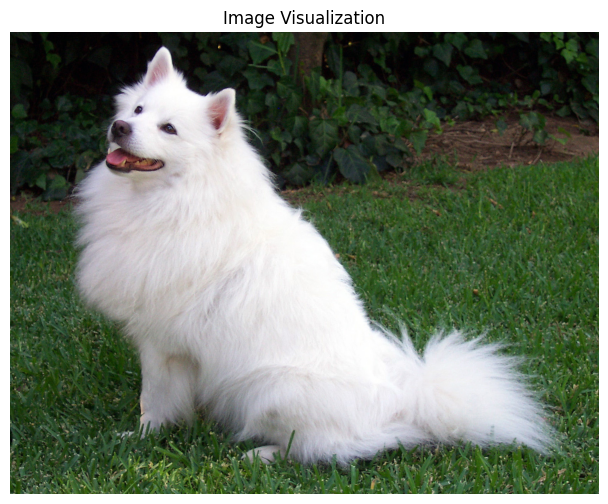

In [27]:
plt.figure(figsize=(8,6))

plt.imshow(image)
plt.axis("off")
plt.title("Image Visualization")

plt.show()

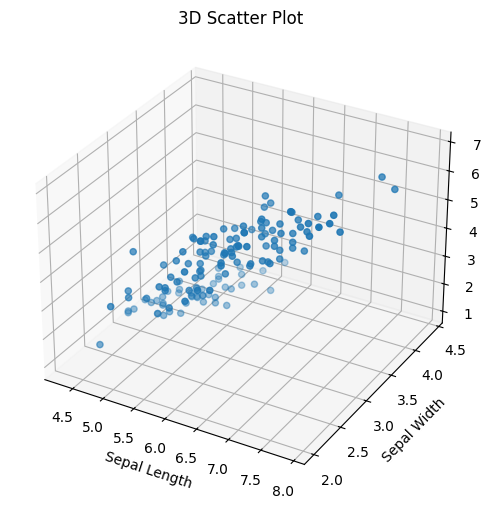

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_csv["sepal_length"],
    df_csv["sepal_width"],
    df_csv["petal_length"]
)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

plt.title("3D Scatter Plot")
plt.show()

In [29]:
from google.colab import files

uploaded = files.upload()

Saving file_example_MP4_480_1_5MG.mp4 to file_example_MP4_480_1_5MG.mp4


In [31]:
from IPython.display import Video

video_file = list(uploaded.keys())[0]

Video(video_file, embed=True)

In [32]:
uploaded = files.upload()

Saving file_example_MP3_700KB.mp3 to file_example_MP3_700KB.mp3


In [33]:
from IPython.display import Audio

audio_file = list(uploaded.keys())[0]

Audio(audio_file)

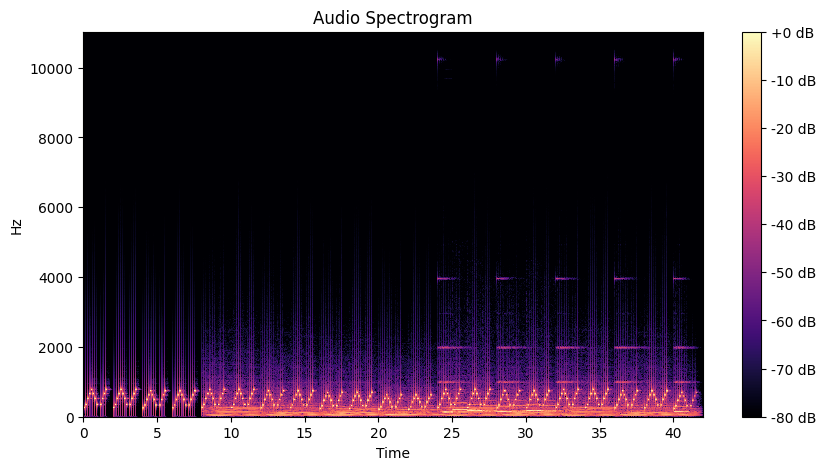

In [34]:
import librosa
import librosa.display

audio_file = list(uploaded.keys())[0]

y, sr = librosa.load(audio_file)

plt.figure(figsize=(10,5))

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Audio Spectrogram")
plt.show()

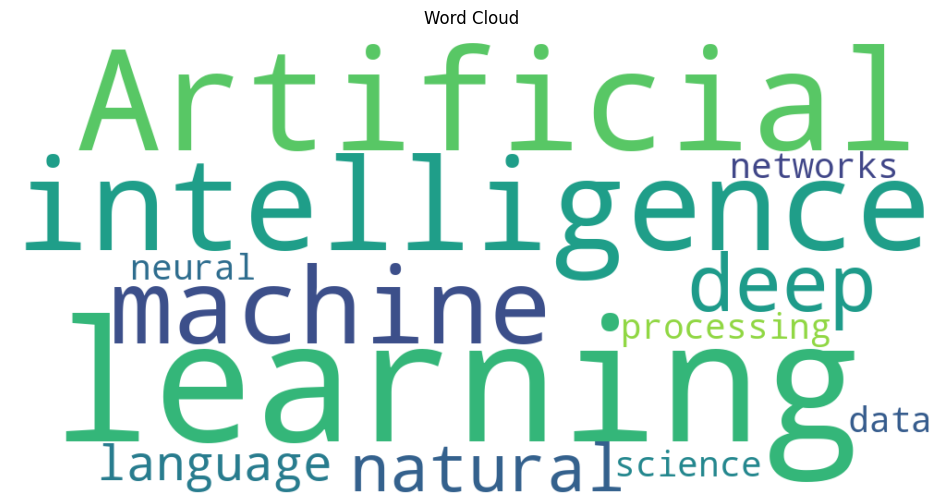

In [35]:
from wordcloud import WordCloud

text = """
Artificial intelligence machine learning deep learning
natural language processing artificial intelligence
machine learning data science neural networks
"""

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

**TASK2**

In [36]:
paragraphs = [

"""OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!!
It was soooo gooood lol. I <3 nlp butttt i hate spelng errors in textttt.
This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%.
The website's link is www.example.com//// Check it out ASAP!!! #excited""",

"""Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web.
This article, "The Marvels of Artificial General Intelligence & the Future of Humanity,"
totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz.
I mean, I <3 NLP butttt those annoying typos in texts drive me nuts.
Brace yourselves, this is gonna be one seriously long paragraph with tons and tons of
extraterrestrial spaces and some seriously weird symbols like @#$%.
And guess what? The link to the website is www.incrediblenews.com////
So, um, you better check it out like ASAP!!! #excitedmuch""",

"""yaaayyyy!!! just watched thisssss AMAZZZING vid on AI & how it’s changin'
evrythinggg!! it waz soooo dopeee, i can’t even... lolzzz! #blessed #mindblownn...
btw, the link is http://coolai.stuff.com//// totally worthhh ittttttt @@@!!!
i <3 tech so much but sometimes it's likee realllyyy confusingggg!!!""",

"""nooo waayyyyy!!!! this is, like, the 1000000th time i've seen ppl mess up spellings in
their blogsssss i mean c'mon, u're writing abt deep learning, not sum joke topic
anywayzzzz... the article was kinda cooool butttt had lotsa weird $$$%%%@@ symbols all
over. you can read it @ www.badblogger.ai//// and let me knw ur thots ASAP!!!""",

"""heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? like for realll...
it wuz crazzzzy detailed but sooooo complicateddd!!! i cud barely undrstnd half of it .
the diagrams were tho!!! i found it here – www.quantmgeekzz.net//// … plz plz plz read n
tell me what u thinkk #toomuchinfo #brainhurts @@@!!!"""
]

print("Number of paragraphs:", len(paragraphs))

Number of paragraphs: 5


In [37]:
def clean_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Handle contractions
    contractions = {
        "can't": "cannot",
        "can’t": "cannot",
        "i'm": "i am",
        "i’m": "i am",
        "it's": "it is",
        "it’s": "it is",
        "i've": "i have",
        "i’ve": "i have",
        "i'd": "i would",
        "i’d": "i would",
        "i'll": "i will",
        "i’ll": "i will",
        "don't": "do not",
        "don't": "do not",
        "didn't": "did not",
        "didn’t": "did not",
        "can't": "cannot",
        "can’t": "cannot",
        "u're": "you are",
        "you're": "you are",
        "you’re": "you are",
        "c'mon": "come on",
        "i <3": "i love"
    }

    for contraction, replacement in contractions.items():
        text = text.replace(contraction, replacement)

    # Special internet expressions
    text = text.replace("<3", "love")

    # Common informal/typo corrections
    corrections = {
        "leanring": "learning",
        "spelng": "spelling",
        "waz": "was",
        "wuz": "was",
        "evrythinggg": "everything",
        "ppl": "people",
        "abt": "about",
        "sum": "some",
        "lotsa": "lots of",
        "knw": "know",
        "thots": "thoughts",
        "cud": "could",
        "undrstnd": "understand",
        "vid": "video",
        "yaaayyyy": "yay",
        "heyyyyy": "hey",
        "nooo": "no",
        "waayyyyy": "way",
        "kinda": "kind of"
    }

    for wrong, correct in corrections.items():
        text = text.replace(wrong, correct)

    # 5. Reduce duplicate letters
    # Four or more repeated characters -> two characters
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)

    # Additional common normalization
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 6. Fix punctuation / remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove standalone numbers if desired
    # Keep 1000000th because it is part of original content
    text = re.sub(r'\s+', ' ', text)

    # 7. Remove extra whitespace
    text = text.strip()

    return text

In [38]:
cleaned_paragraphs = []

for paragraph in paragraphs:
    cleaned = clean_text(paragraph)
    cleaned_paragraphs.append(cleaned)

for i, text in enumerate(cleaned_paragraphs, 1):
    print(f"\nParagraph {i}:")
    print(text)


Paragraph 1:
omg i cannot believe i found this awesome article about ai machine learning it was soo good lol i love nlp butt i hate spelling errors in textt this is gonna be a long paragraph with loots of spaces and weirdd symbols the website s link is check it out asap excited

Paragraph 2:
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mindd it was like so mind blowingly awesome lolz i mean i love nlp butt those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excitedmuch

Paragraph 3:
yay just watched thiss amazing video on ai how it is changin everything it was soo dope i cannot even lolz blessed mindblownn btw the link is totally 

In [39]:
text = paragraphs[0]

lower_text = text.lower()

print(lower_text)

omg!! i can't believe i found this awesome article about ai & machine leanring!! 
it was soooo gooood lol. i <3 nlp butttt i hate spelng errors in textttt. 
this is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
the website's link is www.example.com//// check it out asap!!! #excited


In [40]:
text = "This     is    an      example      text."

cleaned = re.sub(r'\s+', ' ', text).strip()

print(cleaned)

This is an example text.


In [41]:
text = "I can't believe it's amazing. I'm happy."

text = text.replace("can't", "cannot")
text = text.replace("it's", "it is")
text = text.replace("I'm", "I am")

print(text)

I cannot believe it is amazing. I am happy.


In [42]:
text = "AI & ML @#$% is amazing!!!"

cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', text)

print(cleaned)

AI  ML  is amazing


In [43]:
text = "soooo gooood loooong heyyyy"

cleaned = re.sub(r'(.)\1{2,}', r'\1', text)

print(cleaned)

so god long hey


In [44]:
text = "OMG!!!! This is amazing???? Really......"

cleaned = re.sub(r'[!?.,]{2,}', lambda m: m.group(0)[0], text)

print(cleaned)

OMG! This is amazing? Really.


In [45]:
text = "Visit www.example.com//// for more information."

cleaned = re.sub(
    r'https?://\S+|www\.\S+',
    '',
    text
)

print(cleaned)

Visit  for more information.


NLP EXPERIMENT 1

In [46]:
import nltk

nltk.download("brown")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [47]:
from nltk.corpus import brown

words = brown.words(categories="news")

print("Total words:", len(words))
print("First 50 words:")
print(words[:50])

Total words: 100554
First 50 words:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise']


In [48]:
brown_text = " ".join(words)

print(brown_text[:1000])

The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. . `` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' . The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous '' . It recommended that Fulton legislators act `` to have th

In [49]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(brown_text)

print("Total tokens:", len(tokens))
print(tokens[:50])

Total tokens: 101929
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``', 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the']


EXPERIMENT 2

In [50]:
from nltk.probability import FreqDist

fdist = FreqDist(tokens)

print("Most common 20 words:")
print(fdist.most_common(20))

Most common 20 words:
[('the', 5580), (',', 5188), ('.', 4180), ('of', 2849), ('and', 2146), ('to', 2116), ('a', 1993), ('in', 1893), ('``', 1434), ('for', 943), ('that', 811), ('The', 806), ('is', 739), ('was', 720), ("'s", 679), ('on', 657), ('at', 598), ('with', 545), ('be', 526), ('by', 497)]


In [51]:
clean_tokens = [
    word.lower()
    for word in tokens
    if word.isalpha()
]

fdist_clean = FreqDist(clean_tokens)

print(fdist_clean.most_common(20))

[('the', 6386), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2139), ('in', 2020), ('for', 969), ('that', 843), ('is', 740), ('was', 720), ('on', 691), ('he', 658), ('at', 636), ('with', 567), ('be', 526), ('as', 517), ('by', 504), ('it', 504), ('his', 428), ('said', 406)]


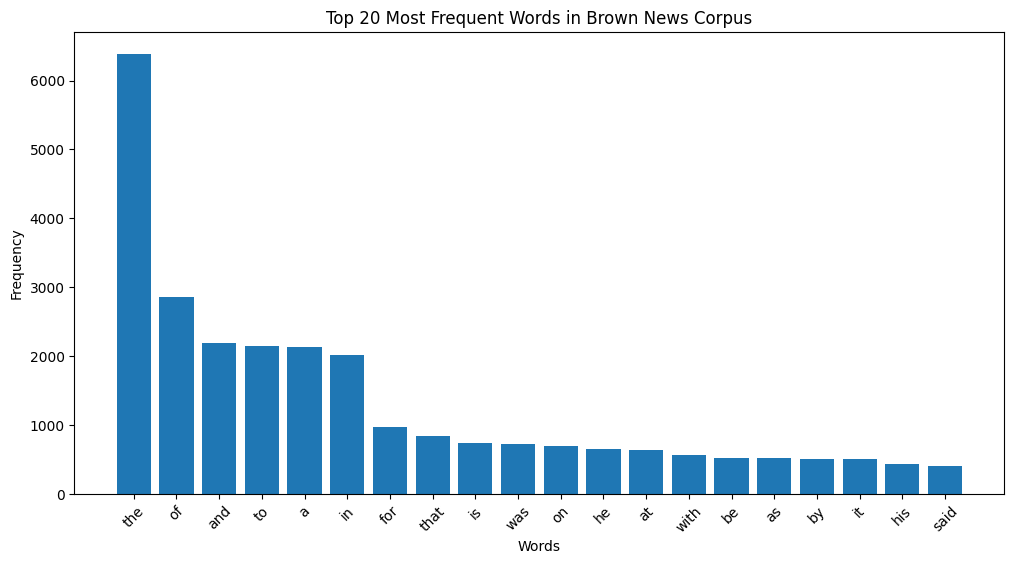

In [52]:
top20 = fdist_clean.most_common(20)

words20 = [x[0] for x in top20]
counts20 = [x[1] for x in top20]

plt.figure(figsize=(12,6))

plt.bar(words20, counts20)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in Brown News Corpus")

plt.xticks(rotation=45)

plt.show()

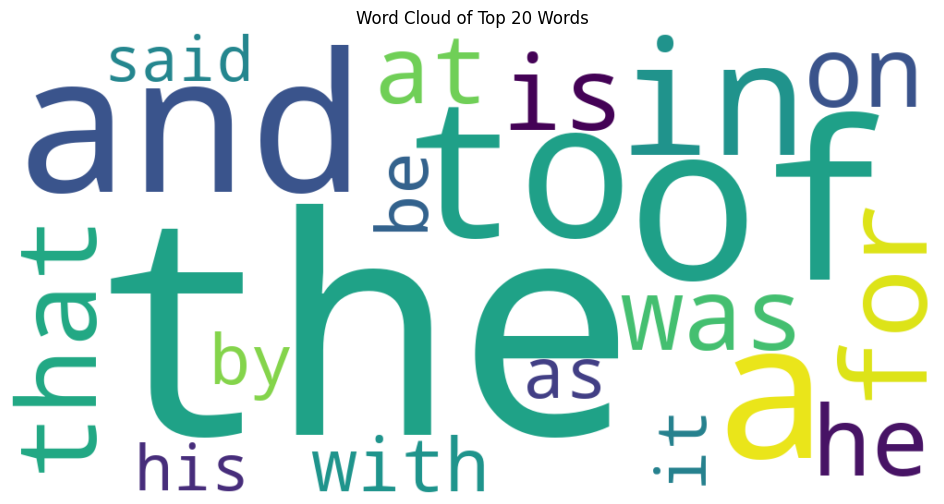

In [53]:
from wordcloud import WordCloud

word_freq = dict(top20)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Top 20 Words")

plt.show()

**EXPERMINET 3**

In [54]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in clean_tokens
]

print("Original → Stemmed")

for original, stemmed in zip(clean_tokens[:50], stemmed_words[:50]):
    print(original, "→", stemmed)

Original → Stemmed
the → the
fulton → fulton
county → counti
grand → grand
jury → juri
said → said
friday → friday
an → an
investigation → investig
of → of
atlanta → atlanta
recent → recent
primary → primari
election → elect
produced → produc
no → no
evidence → evid
that → that
any → ani
irregularities → irregular
took → took
place → place
the → the
jury → juri
further → further
said → said
in → in
presentments → present
that → that
the → the
city → citi
executive → execut
committee → committe
which → which
had → had
charge → charg
of → of
the → the
election → elect
deserves → deserv
the → the
praise → prais
and → and
thanks → thank
of → of
the → the
city → citi
of → of
atlanta → atlanta
for → for


In [55]:
stem_freq = Counter(stemmed_words)

print("Top 30 stemmed words:")

for word, count in stem_freq.most_common(30):
    print(word, ":", count)

Top 30 stemmed words:
the : 6386
of : 2861
and : 2186
to : 2144
a : 2139
in : 2020
for : 969
that : 843
is : 740
wa : 720
on : 691
it : 682
he : 658
at : 636
be : 583
with : 567
as : 517
by : 504
hi : 428
said : 406
will : 396
from : 353
are : 334
thi : 320
an : 311
ha : 304
had : 283
but : 283
have : 279
they : 278


**EXPERIMENT 4**

In [56]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in clean_tokens
]

print("Original → Lemmatized")

for original, lemma in zip(clean_tokens[:50], lemmatized_words[:50]):
    print(original, "→", lemma)

Original → Lemmatized
the → the
fulton → fulton
county → county
grand → grand
jury → jury
said → said
friday → friday
an → an
investigation → investigation
of → of
atlanta → atlanta
recent → recent
primary → primary
election → election
produced → produced
no → no
evidence → evidence
that → that
any → any
irregularities → irregularity
took → took
place → place
the → the
jury → jury
further → further
said → said
in → in
presentments → presentment
that → that
the → the
city → city
executive → executive
committee → committee
which → which
had → had
charge → charge
of → of
the → the
election → election
deserves → deserves
the → the
praise → praise
and → and
thanks → thanks
of → of
the → the
city → city
of → of
atlanta → atlanta
for → for


In [57]:
lemma_freq = Counter(lemmatized_words)

print("Top 30 lemmatized words:")

for word, count in lemma_freq.most_common(30):
    print(word, ":", count)

Top 30 lemmatized words:
the : 6386
of : 2861
a : 2656
and : 2186
to : 2144
in : 2020
for : 969
that : 843
is : 740
wa : 720
on : 691
it : 682
he : 658
at : 636
with : 567
be : 526
by : 504
his : 428
said : 406
will : 389
from : 353
are : 334
this : 320
an : 311
ha : 304
had : 283
but : 283
they : 278
not : 272
who : 268


**EXPERIMENT 5**

In [58]:
comparison_words = [
    "running",
    "runs",
    "runner",
    "studies",
    "studying",
    "studied",
    "better",
    "cats",
    "dogs",
    "playing",
    "played",
    "plays",
    "connected",
    "connection",
    "easily"
]

In [59]:
comparison = []

for word in comparison_words:

    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)

    comparison.append([
        word,
        stem,
        lemma
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Original Word", "Stemmed", "Lemmatized"]
)

comparison_df

,Original Word,Stemmed,Lemmatized
0,running,run,running
1,runs,run,run
2,runner,runner,runner
3,studies,studi,study
4,studying,studi,studying
5,studied,studi,studied
6,better,better,better
7,cats,cat,cat
8,dogs,dog,dog
9,playing,play,playing


In [60]:
comparison_frequency = []

for word in comparison_words:

    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)

    comparison_frequency.append([
        word,
        stem_freq.get(stem, 0),
        lemma_freq.get(lemma, 0)
    ])

frequency_df = pd.DataFrame(
    comparison_frequency,
    columns=[
        "Original Word",
        "Stem Frequency",
        "Lemma Frequency"
    ]
)

frequency_df

,Original Word,Stem Frequency,Lemma Frequency
0,running,78,13
1,runs,78,65
2,runner,1,1
3,studies,26,16
4,studying,26,3
5,studied,26,7
6,better,29,29
7,cats,1,1
8,dogs,10,10
9,playing,87,20


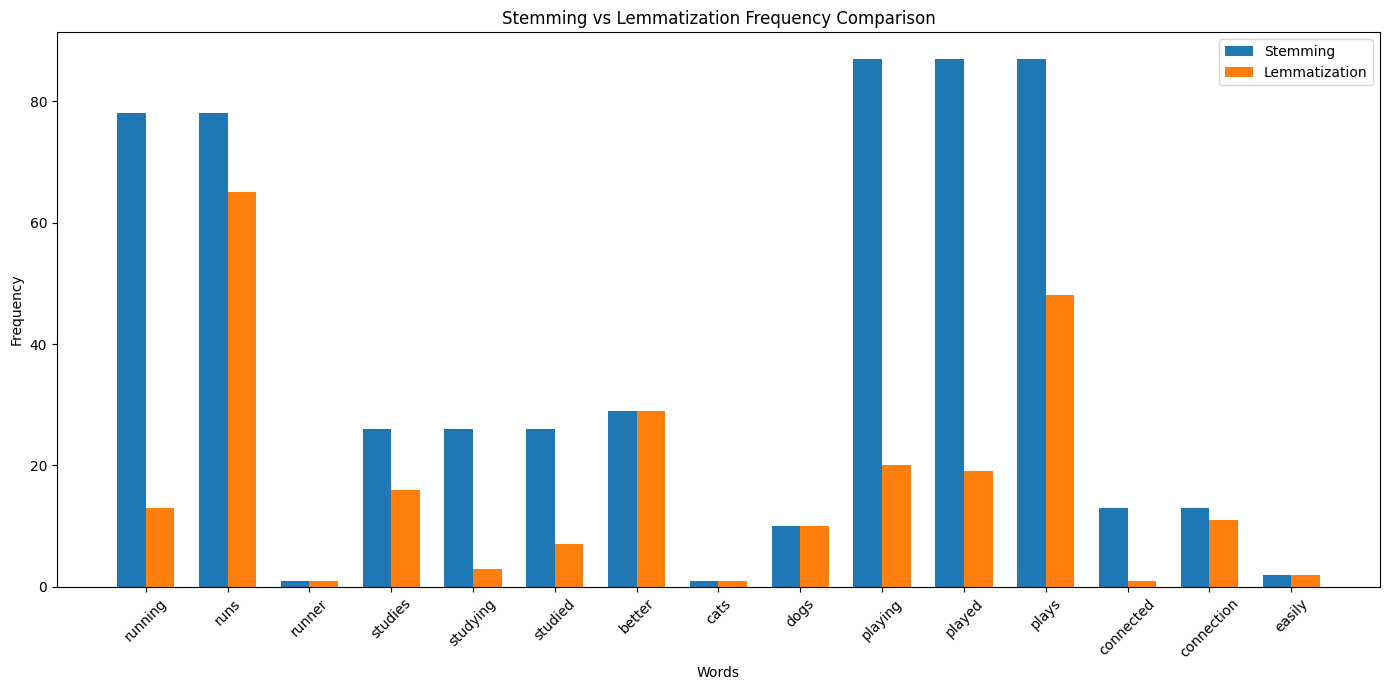

In [61]:
plt.figure(figsize=(14,7))

x = np.arange(len(comparison_words))
width = 0.35

plt.bar(
    x - width/2,
    frequency_df["Stem Frequency"],
    width,
    label="Stemming"
)

plt.bar(
    x + width/2,
    frequency_df["Lemma Frequency"],
    width,
    label="Lemmatization"
)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Stemming vs Lemmatization Frequency Comparison")

plt.xticks(
    x,
    comparison_words,
    rotation=45
)

plt.legend()

plt.tight_layout()
plt.show()

In [62]:
print("=" * 70)
print("TASK 2 - DATA CLEANING RESULTS")
print("=" * 70)

for i, text in enumerate(cleaned_paragraphs, 1):
    print(f"\nParagraph {i}")
    print("-" * 70)
    print(text)

print("\n" + "=" * 70)
print("BROWN CORPUS")
print("=" * 70)

print("Total original tokens:", len(tokens))
print("Total alphabetic tokens:", len(clean_tokens))

print("\nTop 20 Raw Word Frequencies:")
for word, count in fdist_clean.most_common(20):
    print(f"{word:15} {count}")

print("\n" + "=" * 70)
print("TOP STEMMED WORDS")
print("=" * 70)

for word, count in stem_freq.most_common(20):
    print(f"{word:15} {count}")

print("\n" + "=" * 70)
print("TOP LEMMATIZED WORDS")
print("=" * 70)

for word, count in lemma_freq.most_common(20):
    print(f"{word:15} {count}")

TASK 2 - DATA CLEANING RESULTS

Paragraph 1
----------------------------------------------------------------------
omg i cannot believe i found this awesome article about ai machine learning it was soo good lol i love nlp butt i hate spelling errors in textt this is gonna be a long paragraph with loots of spaces and weirdd symbols the website s link is check it out asap excited

Paragraph 2
----------------------------------------------------------------------
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mindd it was like so mind blowingly awesome lolz i mean i love nlp butt those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excit